# Tema 1 - Sistemas de Control Automático

**Fundamentos de Control - GIERM**

---

## Objetivos de aprendizaje

- Comprender qué es un sistema y cómo se relacionan entrada, salida y perturbación
- Diferenciar entre control manual y control automático
- Distinguir entre sistemas en lazo abierto y lazo cerrado (realimentación)
- Clasificar sistemas según distintos criterios: linealidad, continuidad, número de entradas/salidas
- Identificar los componentes fundamentales de un sistema de control (R, E, U, Y, P)
- Reconocer los distintos tipos de ejercicios y resolver problemas de identificación y clasificación

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D
import scipy.signal as signal

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.dpi'] = 100

COLOR_PRINCIPAL = '#2171b5'   # azul - curvas principales
COLOR_RECTA = '#cb181d'       # rojo - límites, referencias
COLOR_PUNTO = '#238b45'       # verde - puntos de operación, resultados OK
COLOR_PERTURB = '#ff7f00'     # naranja - perturbaciones
COLOR_CLARO = '#a6cee3'       # azul claro - señales secundarias

print('Configuración lista.')

Configuración lista.


---

## 1. ¿Qué es un sistema?

Un **sistema** es un conjunto de elementos interrelacionados que transforma una o varias **entradas** en una o varias **salidas**.

Desde el punto de vista del control, todo sistema tiene:

- **Entrada $U(t)$**: la señal que aplicamos al sistema (acción de control)
- **Salida $Y(t)$**: la variable que queremos observar o controlar
- **Perturbación $P(t)$**: factores externos no deseados que afectan a la salida

$$\boxed{Y(t) = f\big(U(t),\; P(t)\big)}$$

El **objetivo del control** es conseguir que $Y(t)$ siga un valor deseado a pesar de las perturbaciones.

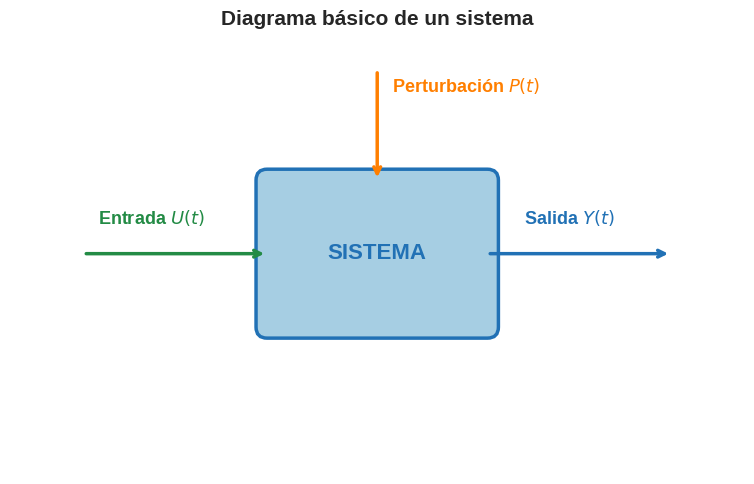

In [2]:
# Diagrama de bloques: Sistema con entrada U, salida Y, perturbación P
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.set_aspect('equal')
ax.axis('off')

# Bloque central: SISTEMA
bloque = FancyBboxPatch((3.5, 2), 3, 2, boxstyle='round,pad=0.15',
                         facecolor=COLOR_CLARO, edgecolor=COLOR_PRINCIPAL, lw=2.5)
ax.add_patch(bloque)
ax.text(5, 3, 'SISTEMA', ha='center', va='center', fontsize=16, fontweight='bold',
        color=COLOR_PRINCIPAL)

# Flecha de entrada U(t)
ax.annotate('', xy=(3.5, 3), xytext=(1, 3),
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=2.5))
ax.text(1.2, 3.4, r'Entrada $U(t)$', fontsize=13, color=COLOR_PUNTO, fontweight='bold')

# Flecha de salida Y(t)
ax.annotate('', xy=(9, 3), xytext=(6.5, 3),
            arrowprops=dict(arrowstyle='->', color=COLOR_PRINCIPAL, lw=2.5))
ax.text(7, 3.4, r'Salida $Y(t)$', fontsize=13, color=COLOR_PRINCIPAL, fontweight='bold')

# Flecha de perturbación P(t)
ax.annotate('', xy=(5, 4), xytext=(5, 5.5),
            arrowprops=dict(arrowstyle='->', color=COLOR_PERTURB, lw=2.5))
ax.text(5.2, 5.2, r'Perturbación $P(t)$', fontsize=13, color=COLOR_PERTURB, fontweight='bold')

ax.set_title(r'Diagrama básico de un sistema', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.1 Ejemplo numérico

**Datos:** Un horno eléctrico recibe una potencia $U = 500$ W. La temperatura exterior (perturbación) es $P = 20$ °C.

$$Y = 0.4 \cdot U + P = 0.4 \times 500 + 20 = 220\;\text{°C}$$

$$\boxed{Y = 220\;\text{°C}}$$

Si la perturbación cambia a $P = 10$ °C (baja la temperatura ambiente):

$$Y = 0.4 \times 500 + 10 = 210\;\text{°C}$$

La salida cambia aunque la entrada sea la misma $\to$ **efecto de la perturbación**.

---

## 2. Control manual vs control automático

- **Control manual**: un operador humano observa la salida y ajusta la entrada. Es lento, impreciso y depende de la atención del operador.
- **Control automático**: un controlador (electrónico, mecánico, etc.) mide la salida y ajusta la entrada de forma continua y rápida.

| Característica | Control manual | Control automático |
|:---|:---|:---|
| Velocidad de respuesta | Lenta (segundos a minutos) | Rápida (milisegundos) |
| Precisión | Baja, depende del operador | Alta, determinada por el diseño |
| Fatiga | Se degrada con el tiempo | Constante 24/7 |
| Coste inicial | Bajo | Mayor (sensores, controlador) |
| Repetibilidad | Mala | Excelente |

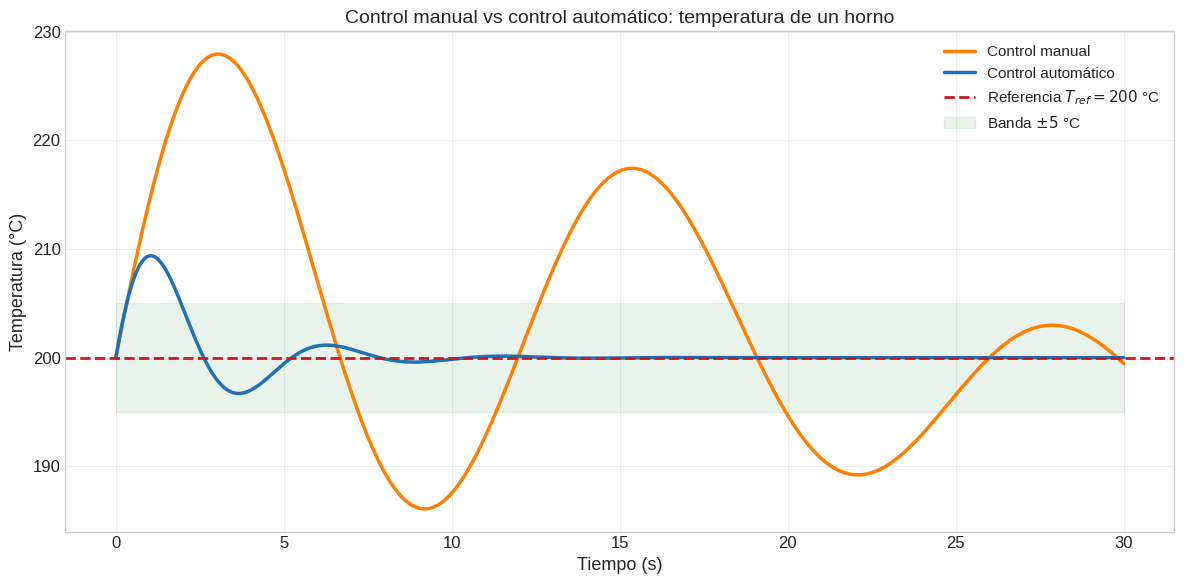

In [3]:
# Comparación: Control manual vs automático (temperatura de un horno)
t = np.linspace(0, 30, 500)
T_ref = 200  # Temperatura deseada

# Control manual: respuesta lenta con oscilaciones grandes
T_manual = T_ref + 30 * np.exp(-0.05 * t) * np.sin(0.5 * t) + 5 * np.sin(0.15 * t)

# Control automático: respuesta rápida con pequeño sobrepico
T_auto = T_ref + 15 * np.exp(-0.4 * t) * np.sin(1.2 * t)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t, T_manual, color=COLOR_PERTURB, lw=2.5, label='Control manual')
ax.plot(t, T_auto, color=COLOR_PRINCIPAL, lw=2.5, label=r'Control automático')
ax.axhline(y=T_ref, color=COLOR_RECTA, ls='--', lw=2, label=r'Referencia $T_{ref}=200$ °C')

ax.fill_between(t, T_ref - 5, T_ref + 5, alpha=0.1, color=COLOR_PUNTO, label=r'Banda $\pm 5$ °C')

ax.set_xlabel('Tiempo (s)')
ax.set_ylabel(r'Temperatura (°C)')
ax.set_title(r'Control manual vs control automático: temperatura de un horno')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.1 Ejemplo numérico

**Datos:** Un operador intenta mantener un horno a $T_{ref} = 200$ °C. Cada vez que mira el termómetro, ajusta la potencia. El control automático usa un sensor y un controlador PID.

Con **control manual**, el operador tarda $\approx 5$ s en reaccionar. La temperatura oscila entre $170$ °C y $230$ °C:

$$\text{Error máximo}_{\text{manual}} = |230 - 200| = 30\;\text{°C}$$

Con **control automático**, el sistema responde en $\approx 0.5$ s. La temperatura oscila entre $195$ °C y $210$ °C:

$$\text{Error máximo}_{\text{auto}} = |210 - 200| = 10\;\text{°C}$$

$$\boxed{\text{Reducción del error} = \frac{30 - 10}{30} \times 100 = 66.7\%}$$

---

## 3. Lazo abierto vs lazo cerrado

### Lazo abierto

La salida **no se mide** ni se compara con la referencia. El controlador actúa "a ciegas".

- **Ventaja**: simple, barato
- **Desventaja**: no corrige perturbaciones, no compensa errores

### Lazo cerrado (realimentación)

La salida **se mide** con un sensor y se compara con la referencia. La diferencia (error) se usa para corregir la acción de control.

$$\boxed{E(t) = R(t) - Y(t)}$$

- **Ventaja**: corrige perturbaciones, reduce errores, robusto
- **Desventaja**: más complejo, puede ser inestable si se diseña mal

| Característica | Lazo abierto | Lazo cerrado |
|:---|:---|:---|
| Sensor de salida | No | Sí |
| Corrige perturbaciones | No | Sí |
| Complejidad | Baja | Mayor |
| Estabilidad | Siempre estable* | Puede ser inestable |
| Precisión | Baja | Alta |

*Si la planta es estable.

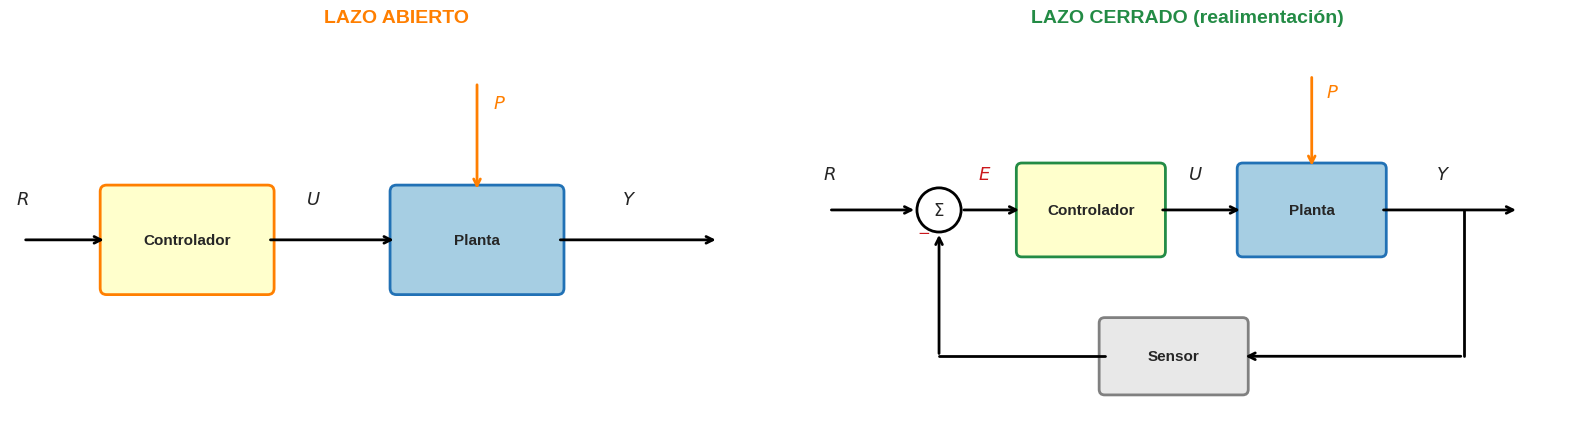

In [4]:
# Diagramas de bloques: Lazo abierto vs Lazo cerrado
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- LAZO ABIERTO ---
ax = axes[0]
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('LAZO ABIERTO', fontsize=14, fontweight='bold', color=COLOR_PERTURB)

# Bloque controlador
ctrl = FancyBboxPatch((1.5, 2), 2.5, 1.5, boxstyle='round,pad=0.1',
                       facecolor='#ffffcc', edgecolor=COLOR_PERTURB, lw=2)
ax.add_patch(ctrl)
ax.text(2.75, 2.75, 'Controlador', ha='center', va='center', fontsize=11, fontweight='bold')

# Bloque planta
planta = FancyBboxPatch((6, 2), 2.5, 1.5, boxstyle='round,pad=0.1',
                         facecolor=COLOR_CLARO, edgecolor=COLOR_PRINCIPAL, lw=2)
ax.add_patch(planta)
ax.text(7.25, 2.75, 'Planta', ha='center', va='center', fontsize=11, fontweight='bold')

# Flechas
ax.annotate('', xy=(1.5, 2.75), xytext=(0.2, 2.75),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.text(0.1, 3.3, r'$R$', fontsize=13, fontweight='bold')

ax.annotate('', xy=(6, 2.75), xytext=(4, 2.75),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.text(4.6, 3.3, r'$U$', fontsize=13, fontweight='bold')

ax.annotate('', xy=(11, 2.75), xytext=(8.5, 2.75),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.text(9.5, 3.3, r'$Y$', fontsize=13, fontweight='bold')

# Perturbación
ax.annotate('', xy=(7.25, 3.5), xytext=(7.25, 5.2),
            arrowprops=dict(arrowstyle='->', lw=2, color=COLOR_PERTURB))
ax.text(7.5, 4.8, r'$P$', fontsize=13, fontweight='bold', color=COLOR_PERTURB)

# --- LAZO CERRADO ---
ax = axes[1]
ax.set_xlim(0, 14)
ax.set_ylim(-1, 6)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(r'LAZO CERRADO (realimentación)', fontsize=14, fontweight='bold', color=COLOR_PUNTO)

# Sumador
circle = plt.Circle((2.5, 2.75), 0.4, fill=False, edgecolor='black', lw=2)
ax.add_patch(circle)
ax.text(2.5, 2.75, r'$\Sigma$', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(2.1, 2.3, r'$-$', fontsize=11, color=COLOR_RECTA, fontweight='bold')

# Bloque controlador
ctrl = FancyBboxPatch((4, 2), 2.5, 1.5, boxstyle='round,pad=0.1',
                       facecolor='#ffffcc', edgecolor=COLOR_PUNTO, lw=2)
ax.add_patch(ctrl)
ax.text(5.25, 2.75, 'Controlador', ha='center', va='center', fontsize=11, fontweight='bold')

# Bloque planta
planta = FancyBboxPatch((8, 2), 2.5, 1.5, boxstyle='round,pad=0.1',
                         facecolor=COLOR_CLARO, edgecolor=COLOR_PRINCIPAL, lw=2)
ax.add_patch(planta)
ax.text(9.25, 2.75, 'Planta', ha='center', va='center', fontsize=11, fontweight='bold')

# Bloque sensor
sensor = FancyBboxPatch((5.5, -0.5), 2.5, 1.2, boxstyle='round,pad=0.1',
                         facecolor='#e8e8e8', edgecolor='gray', lw=2)
ax.add_patch(sensor)
ax.text(6.75, 0.1, 'Sensor', ha='center', va='center', fontsize=11, fontweight='bold')

# Flechas principales
ax.annotate('', xy=(2.1, 2.75), xytext=(0.5, 2.75),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.text(0.4, 3.3, r'$R$', fontsize=13, fontweight='bold')

ax.annotate('', xy=(4, 2.75), xytext=(2.9, 2.75),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.text(3.2, 3.3, r'$E$', fontsize=13, fontweight='bold', color=COLOR_RECTA)

ax.annotate('', xy=(8, 2.75), xytext=(6.5, 2.75),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.text(7, 3.3, r'$U$', fontsize=13, fontweight='bold')

ax.annotate('', xy=(13, 2.75), xytext=(10.5, 2.75),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.text(11.5, 3.3, r'$Y$', fontsize=13, fontweight='bold')

# Perturbación
ax.annotate('', xy=(9.25, 3.5), xytext=(9.25, 5.2),
            arrowprops=dict(arrowstyle='->', lw=2, color=COLOR_PERTURB))
ax.text(9.5, 4.8, r'$P$', fontsize=13, fontweight='bold', color=COLOR_PERTURB)

# Realimentación
ax.plot([12, 12], [2.75, 0.1], color='black', lw=2)
ax.annotate('', xy=(8, 0.1), xytext=(12, 0.1),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.plot([5.5, 2.5], [0.1, 0.1], color='black', lw=2)
ax.annotate('', xy=(2.5, 2.35), xytext=(2.5, 0.1),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))

plt.tight_layout()
plt.show()

### 3.1 Ejemplo numérico: Ventaja de la realimentación

**Datos:** Queremos mantener la velocidad de un motor a $R = 1000$ rpm. La planta tiene ganancia $G_p = 2$, el controlador $G_c = 5$.

**Lazo abierto (sin sensor):**

$$Y = G_c \cdot G_p \cdot R = 5 \times 2 \times 1000 = 10000\;\text{rpm}$$

Evidentemente hay que calibrar. Si ajustamos $G_c = 0.1$:

$$Y = 0.1 \times 2 \times 1000 = 200\;\text{rpm} \quad \text{(no llega)}$$

Requiere calibración exacta y no corrige perturbaciones.

**Lazo cerrado:**

$$Y = \frac{G_c \cdot G_p}{1 + G_c \cdot G_p} \cdot R = \frac{5 \times 2}{1 + 5 \times 2} \times 1000 = \frac{10}{11} \times 1000 = 909\;\text{rpm}$$

$$\boxed{Y_{\text{lazo cerrado}} = 909\;\text{rpm}}$$

Con realimentación, aunque no sea perfecto, la salida se acerca automáticamente a la referencia. Si aumentamos $G_c$, la salida se acerca más a $R$.

---

## 4. Clasificación de sistemas

Los sistemas de control se clasifican según varios criterios:

| Criterio | Tipo A | Tipo B | Ejemplo A | Ejemplo B |
|:---|:---|:---|:---|:---|
| Memoria | **Estático** (sin memoria) | **Dinámico** (con memoria) | Resistencia ($V = R \cdot I$) | Condensador ($V = \frac{1}{C}\int I\,dt$) |
| Linealidad | **Lineal** | **No lineal** | Amplificador ideal | Motor con saturación |
| Tiempo | **Continuo** | **Discreto** | Circuito analógico | Microcontrolador muestreando |
| Entradas/Salidas | **SISO** | **MIMO** | Control de temperatura (1 sensor, 1 actuador) | Robot (múltiples motores y sensores) |
| Parámetros | **Invariante** en el tiempo (LTI) | **Variante** en el tiempo | Motor con carga constante | Cohete (cambia masa al gastar combustible) |
| Causalidad | **Causal** | **No causal** | Todo sistema físico real | Filtro ideal (teórico) |

**Nota importante:** En esta asignatura trabajaremos principalmente con sistemas **lineales, continuos, invariantes en el tiempo (LTI) y SISO**.

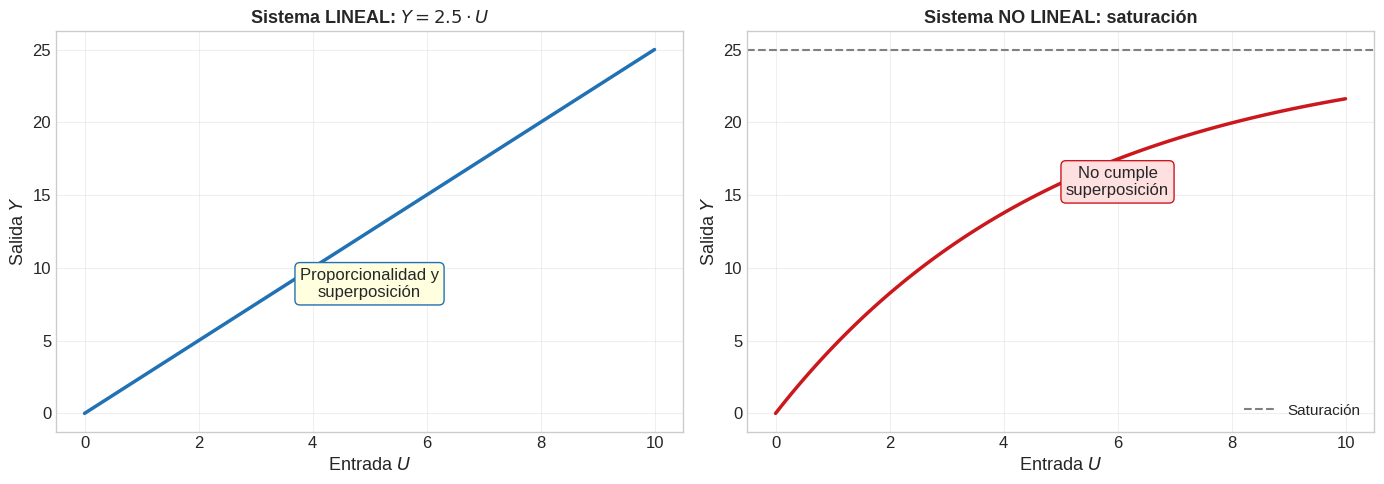

In [5]:
# Ejemplo visual: Sistema lineal vs no lineal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lineal
u_lin = np.linspace(0, 10, 100)
y_lin = 2.5 * u_lin
axes[0].plot(u_lin, y_lin, color=COLOR_PRINCIPAL, lw=2.5)
axes[0].set_xlabel(r'Entrada $U$')
axes[0].set_ylabel(r'Salida $Y$')
axes[0].set_title(r'Sistema LINEAL: $Y = 2.5 \cdot U$', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].text(5, 8, 'Proporcionalidad y\nsuperposici\u00f3n',
             fontsize=12, ha='center',
             bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor=COLOR_PRINCIPAL))

# No lineal (con saturación)
u_nlin = np.linspace(0, 10, 100)
y_nlin = 25 * (1 - np.exp(-0.2 * u_nlin))  # saturación
axes[1].plot(u_nlin, y_nlin, color=COLOR_RECTA, lw=2.5)
axes[1].axhline(y=25, color='gray', ls='--', lw=1.5, label=r'Saturación')
axes[1].set_xlabel(r'Entrada $U$')
axes[1].set_ylabel(r'Salida $Y$')
axes[1].set_title(r'Sistema NO LINEAL: saturación', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)
axes[1].text(6, 15, 'No cumple\nsuperposici\u00f3n',
             fontsize=12, ha='center',
             bbox=dict(boxstyle='round', facecolor='#ffe0e0', edgecolor=COLOR_RECTA))

plt.tight_layout()
plt.show()

### 4.1 Ejemplo numérico: Verificación de linealidad

**Datos:** Un sistema tiene $Y = 3U + 2$.

**¿Es lineal?** Verificamos con el principio de **superposición**:

- Para $U_1 = 1$: $Y_1 = 3(1) + 2 = 5$
- Para $U_2 = 2$: $Y_2 = 3(2) + 2 = 8$
- Para $U_1 + U_2 = 3$: $Y_{1+2} = 3(3) + 2 = 11$
- Pero $Y_1 + Y_2 = 5 + 8 = 13 \neq 11$

$$\boxed{Y = 3U + 2 \text{ NO es lineal (tiene término independiente)}}$$

En cambio, $Y = 3U$ **sí es lineal** porque $Y(U_1 + U_2) = Y(U_1) + Y(U_2)$.

---

## 5. Componentes de un sistema de control

Todo sistema de control en lazo cerrado tiene los siguientes componentes:

| Símbolo | Nombre | Descripción |
|:---:|:---|:---|
| $R(t)$ | **Referencia** (*setpoint*) | Valor deseado de la salida |
| $Y(t)$ | **Salida** (variable controlada) | Valor real medido |
| $E(t)$ | **Error** | Diferencia entre referencia y salida: $E = R - Y$ |
| $U(t)$ | **Señal de control** (acción de control) | Señal que el controlador envía al actuador |
| $P(t)$ | **Perturbación** | Factores externos no deseados |
| $G_c$ | **Controlador** | Procesa el error y genera la acción de control |
| $G_p$ | **Planta** (proceso) | El sistema físico que queremos controlar |
| $H$ | **Sensor** | Mide la salida y la realimenta |

---

## 6. Ejemplo: Sistema de control de velocidad de crucero

Un **control de velocidad de crucero** en un coche mantiene la velocidad constante en autopista.

**Identificación de componentes:**

| Componente | En el coche |
|:---:|:---|
| $R$ (Referencia) | Velocidad seleccionada por el conductor (ej. 120 km/h) |
| $Y$ (Salida) | Velocidad real del vehículo (medida por el velocímetro) |
| $E$ (Error) | $E = R - Y$ = diferencia entre velocidad deseada y real |
| $U$ (Control) | Posición del acelerador (apertura de la mariposa) |
| $P$ (Perturbación) | Pendiente de la carretera, viento, cambios de carga |
| Controlador | ECU (unidad electrónica de control) |
| Planta | Motor + transmisión + vehículo |
| Sensor | Sensor de velocidad en la rueda |

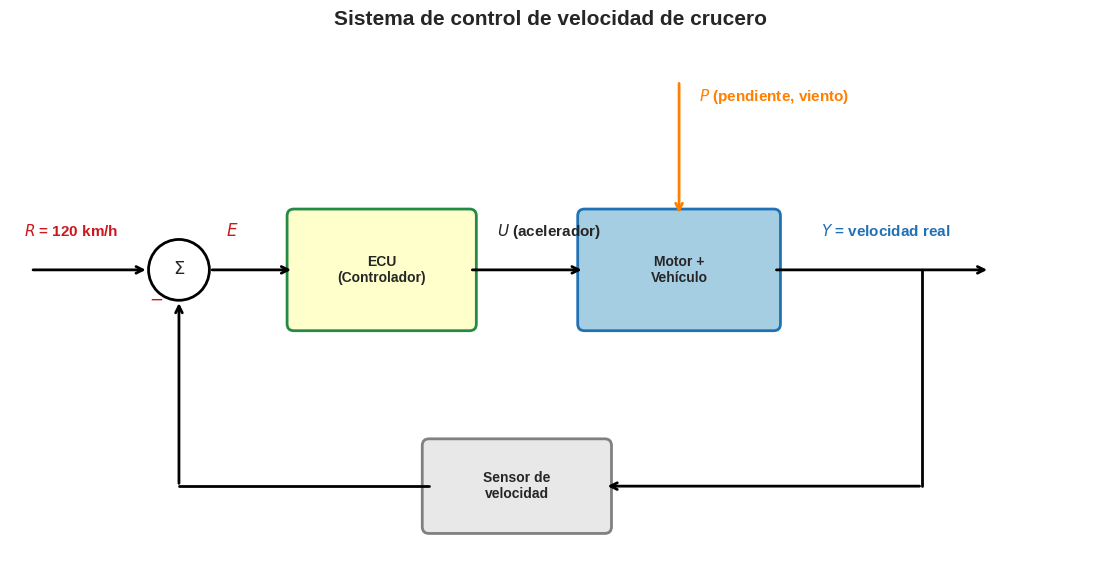

In [6]:
# Diagrama de bloques: Control de velocidad de crucero
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 16)
ax.set_ylim(-1.5, 6.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Sistema de control de velocidad de crucero', fontsize=15, fontweight='bold')

# Sumador
circle = plt.Circle((2.5, 3), 0.45, fill=False, edgecolor='black', lw=2)
ax.add_patch(circle)
ax.text(2.5, 3, r'$\Sigma$', ha='center', va='center', fontsize=13, fontweight='bold')
ax.text(2.05, 2.5, r'$-$', fontsize=12, color=COLOR_RECTA, fontweight='bold')

# Bloque Controlador (ECU)
b1 = FancyBboxPatch((4.2, 2.2), 2.6, 1.6, boxstyle='round,pad=0.1',
                      facecolor='#ffffcc', edgecolor=COLOR_PUNTO, lw=2)
ax.add_patch(b1)
ax.text(5.5, 3, 'ECU\n(Controlador)', ha='center', va='center', fontsize=10, fontweight='bold')

# Bloque Planta (Motor + Coche)
b2 = FancyBboxPatch((8.5, 2.2), 2.8, 1.6, boxstyle='round,pad=0.1',
                      facecolor=COLOR_CLARO, edgecolor=COLOR_PRINCIPAL, lw=2)
ax.add_patch(b2)
ax.text(9.9, 3, 'Motor +\nVeh\u00edculo', ha='center', va='center', fontsize=10, fontweight='bold')

# Bloque Sensor
b3 = FancyBboxPatch((6.2, -0.8), 2.6, 1.2, boxstyle='round,pad=0.1',
                      facecolor='#e8e8e8', edgecolor='gray', lw=2)
ax.add_patch(b3)
ax.text(7.5, -0.2, 'Sensor de\nvelocidad', ha='center', va='center', fontsize=10, fontweight='bold')

# Flechas y etiquetas
# R -> Sumador
ax.annotate('', xy=(2.05, 3), xytext=(0.3, 3),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.text(0.2, 3.5, r'$R$ = 120 km/h', fontsize=11, fontweight='bold', color=COLOR_RECTA)

# Sumador -> Controlador
ax.annotate('', xy=(4.2, 3), xytext=(2.95, 3),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.text(3.2, 3.5, r'$E$', fontsize=12, fontweight='bold', color=COLOR_RECTA)

# Controlador -> Planta
ax.annotate('', xy=(8.5, 3), xytext=(6.8, 3),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.text(7.2, 3.5, r'$U$ (acelerador)', fontsize=11, fontweight='bold')

# Planta -> Salida Y
ax.annotate('', xy=(14.5, 3), xytext=(11.3, 3),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.text(12, 3.5, r'$Y$ = velocidad real', fontsize=11, fontweight='bold', color=COLOR_PRINCIPAL)

# Perturbación
ax.annotate('', xy=(9.9, 3.8), xytext=(9.9, 5.8),
            arrowprops=dict(arrowstyle='->', lw=2, color=COLOR_PERTURB))
ax.text(10.2, 5.5, r'$P$ (pendiente, viento)', fontsize=11, fontweight='bold', color=COLOR_PERTURB)

# Realimentación
ax.plot([13.5, 13.5], [3, -0.2], color='black', lw=2)
ax.annotate('', xy=(8.8, -0.2), xytext=(13.5, -0.2),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.plot([6.2, 2.5], [-0.2, -0.2], color='black', lw=2)
ax.annotate('', xy=(2.5, 2.55), xytext=(2.5, -0.2),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))

plt.tight_layout()
plt.show()

### 6.1 Ejemplo numérico: Crucero ante perturbación

**Datos:** $R = 120$ km/h, velocidad actual $Y = 115$ km/h (el coche sube una cuesta $P > 0$).

**Paso 1:** Calcular el error

$$E = R - Y = 120 - 115 = 5\;\text{km/h}$$

**Paso 2:** El controlador detecta $E > 0$ y aumenta la apertura del acelerador $U$.

**Paso 3:** El motor entrega más potencia $\to$ la velocidad sube.

**Paso 4:** Cuando $Y = 120$ km/h $\to$ $E = 0$ $\to$ el sistema se estabiliza.

$$\boxed{E = R - Y = 120 - 120 = 0\;\text{km/h} \quad \text{(régimen permanente ideal)}}$$

---

## 7. Efecto del control: sistema sin control vs con control

Veamos qué ocurre con la temperatura de un frigorífico cuando se abre la puerta (perturbación):

- **Sin control**: la temperatura sube y no vuelve al valor deseado
- **Con control**: el compresor se activa, la temperatura se recupera

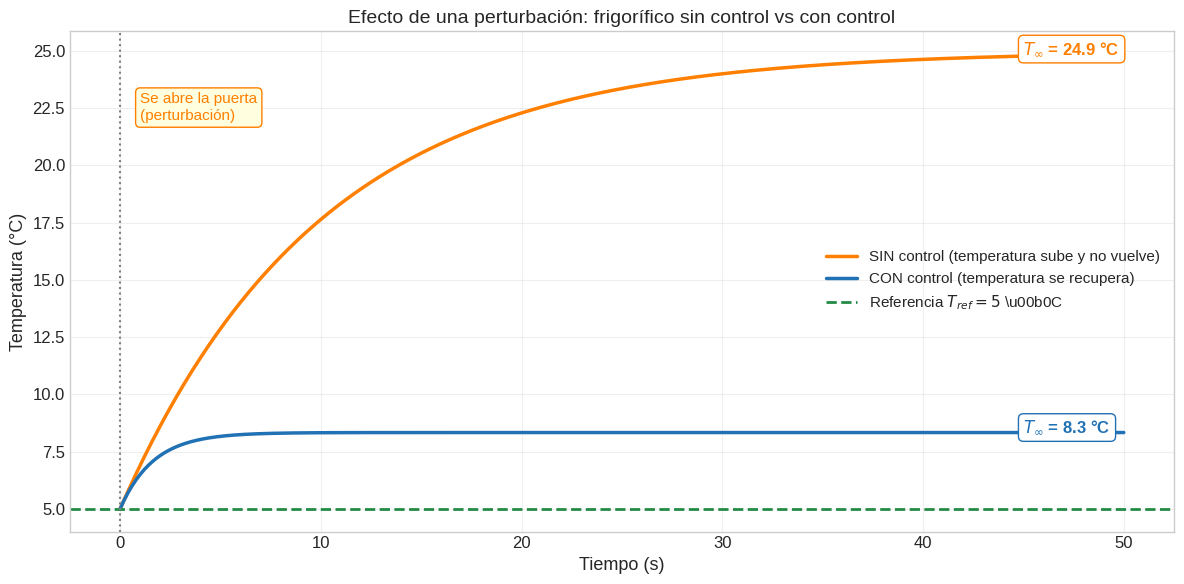

In [7]:
# Respuesta con y sin control ante perturbación usando scipy.signal

# Sistema de primer orden (planta térmica): G(s) = 1 / (10s + 1)
# Controlador proporcional: Gc = 5
# Lazo cerrado ante perturbación: Y/P = G / (1 + Gc*G) = 1 / (10s + 6)

# Sin control: la perturbación pasa directamente por la planta
sys_sin_control = signal.TransferFunction([1], [10, 1])

# Con control proporcional Kp=5
sys_con_control = signal.TransferFunction([1], [10, 6])

t_sim = np.linspace(0, 50, 500)
t1, y1 = signal.step(sys_sin_control, T=t_sim)
t2, y2 = signal.step(sys_con_control, T=t_sim)

# Temperatura base 5°C, perturbación de +20°C (puerta abierta)
T_ref = 5
perturbacion = 20
T_sin = T_ref + perturbacion * y1
T_con = T_ref + perturbacion * y2

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t1, T_sin, color=COLOR_PERTURB, lw=2.5, label='SIN control (temperatura sube y no vuelve)')
ax.plot(t2, T_con, color=COLOR_PRINCIPAL, lw=2.5, label='CON control (temperatura se recupera)')
ax.axhline(y=T_ref, color=COLOR_PUNTO, ls='--', lw=2, label=r'Referencia $T_{ref}=5$ \u00b0C')

# Marcar momento de perturbación
ax.axvline(x=0, color='gray', ls=':', lw=1.5)
ax.text(1, 22, 'Se abre la puerta\n(perturbación)',
        fontsize=11, color=COLOR_PERTURB,
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor=COLOR_PERTURB))

# Anotar valores finales
ax.annotate(f'$T_{{\\infty}}$ = {T_sin[-1]:.1f} \u00b0C', xy=(45, T_sin[-1]),
            fontsize=12, color=COLOR_PERTURB, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PERTURB))
ax.annotate(f'$T_{{\\infty}}$ = {T_con[-1]:.1f} \u00b0C', xy=(45, T_con[-1]),
            fontsize=12, color=COLOR_PRINCIPAL, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PRINCIPAL))

ax.set_xlabel('Tiempo (s)')
ax.set_ylabel(r'Temperatura (°C)')
ax.set_title(r'Efecto de una perturbación: frigorífico sin control vs con control')
ax.legend(fontsize=11, loc='center right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.1 Ejemplo numérico

**Datos:** Planta térmica $G_p(s) = \frac{1}{10s + 1}$, controlador proporcional $K_p = 5$, perturbación $P = 20$ °C.

**Sin control** (lazo abierto), en régimen permanente ($s = 0$):

$$Y_{\infty} = G_p(0) \cdot P = \frac{1}{1} \times 20 = 20\;\text{°C de incremento}$$

$$T_{\text{final}} = 5 + 20 = 25\;\text{°C}$$

**Con control** (lazo cerrado), la función de transferencia perturbación-salida:

$$\frac{Y}{P} = \frac{G_p}{1 + K_p \cdot G_p} = \frac{\frac{1}{10s+1}}{1 + \frac{5}{10s+1}} = \frac{1}{10s + 6}$$

En régimen permanente ($s = 0$):

$$Y_{\infty} = \frac{1}{6} \times 20 = 3.33\;\text{°C de incremento}$$

$$T_{\text{final}} = 5 + 3.33 = 8.33\;\text{°C}$$

$$\boxed{\text{Reducción del efecto: } \frac{20 - 3.33}{20} \times 100 = 83.3\%}$$

La realimentación reduce el efecto de la perturbación por un factor de $1 + K_p \cdot G_p(0) = 1 + 5 = 6$.

---

## 8. Respuesta temporal de un sistema de control

Los sistemas de control se caracterizan por su **respuesta ante un escalón** (entrada que cambia bruscamente de 0 a 1). Los parámetros clave son:

- **Tiempo de subida** ($t_r$): tiempo en llegar del 10% al 90% del valor final
- **Sobreoscilación** ($M_p$): cuánto se pasa del valor final, en porcentaje
- **Tiempo de establecimiento** ($t_s$): tiempo en quedarse dentro de una banda ($\pm 2\%$ o $\pm 5\%$)
- **Error en régimen permanente** ($e_{ss}$): diferencia entre referencia y salida cuando $t \to \infty$

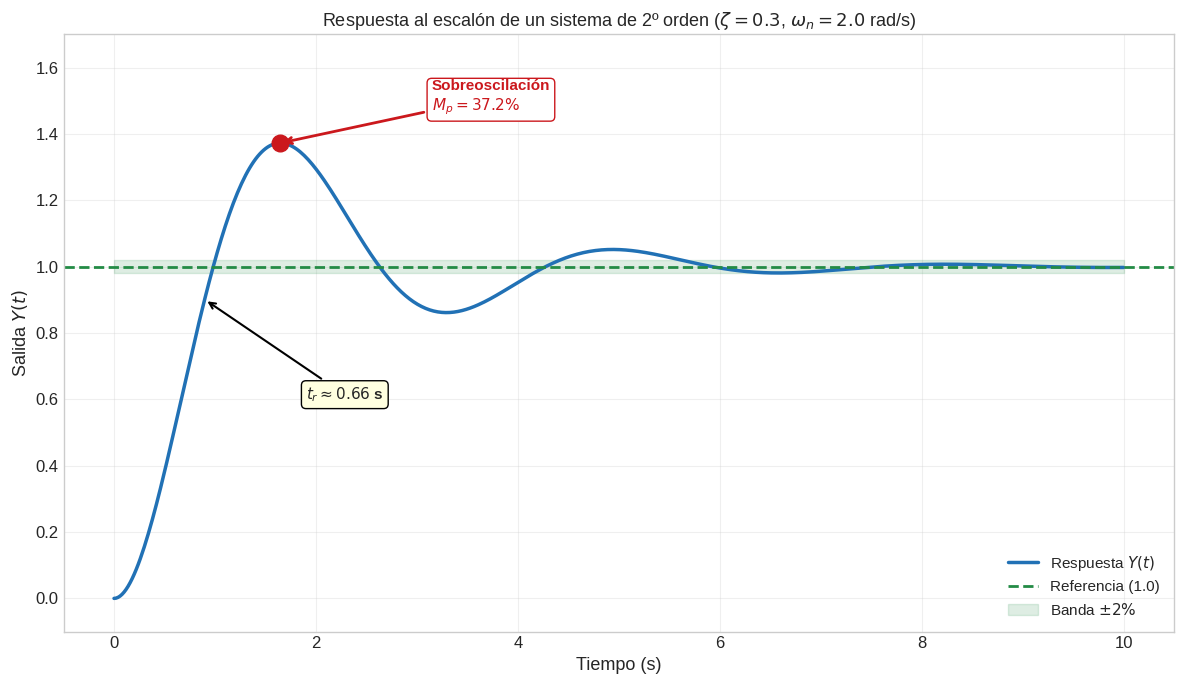

In [8]:
# Respuesta al escalón: sistema subamortiguado con parámetros temporales
# Sistema de segundo orden: G(s) = wn^2 / (s^2 + 2*zeta*wn*s + wn^2)
wn = 2.0   # frecuencia natural
zeta = 0.3 # factor de amortiguamiento (subamortiguado)

sys_2orden = signal.TransferFunction([wn**2], [1, 2*zeta*wn, wn**2])
t_sim = np.linspace(0, 10, 500)
t_resp, y_resp = signal.step(sys_2orden, T=t_sim)

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(t_resp, y_resp, color=COLOR_PRINCIPAL, lw=2.5, label=r'Respuesta $Y(t)$')
ax.axhline(y=1, color=COLOR_PUNTO, ls='--', lw=2, label='Referencia (1.0)')

# Sobreoscilación
Mp = np.exp(-zeta * np.pi / np.sqrt(1 - zeta**2))
tp = np.pi / (wn * np.sqrt(1 - zeta**2))
ax.plot(tp, 1 + Mp, 'o', color=COLOR_RECTA, ms=12, zorder=5)
ax.annotate(f'Sobreoscilaci\u00f3n\n$M_p = {Mp*100:.1f}\\%$',
            xy=(tp, 1 + Mp), xytext=(tp + 1.5, 1 + Mp + 0.1),
            fontsize=11, color=COLOR_RECTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_RECTA, lw=2),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_RECTA))

# Banda del 2%
ax.fill_between(t_resp, 0.98, 1.02, alpha=0.15, color=COLOR_PUNTO, label=r'Banda $\pm 2\%$')

# Tiempo de subida aproximado
idx_10 = np.argmin(np.abs(y_resp - 0.1))
idx_90 = np.argmin(np.abs(y_resp[:np.argmax(y_resp)] - 0.9))
tr = t_resp[idx_90] - t_resp[idx_10]
ax.annotate(f'$t_r \\approx {tr:.2f}$ s', xy=(t_resp[idx_90], 0.9),
            xytext=(t_resp[idx_90] + 1, 0.6),
            fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', lw=1.5),
            bbox=dict(boxstyle='round', facecolor='lightyellow'))

ax.set_xlabel('Tiempo (s)')
ax.set_ylabel(r'Salida $Y(t)$')
ax.set_title(r'Respuesta al escalón de un sistema de 2º orden'
             f' ($\\zeta={zeta}$, $\\omega_n={wn}$ rad/s)', fontsize=13)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 1.7)
plt.tight_layout()
plt.show()

### 8.1 Ejemplo numérico: Parámetros temporales

**Datos:** Sistema de segundo orden con $\omega_n = 2$ rad/s, $\zeta = 0.3$.

**Sobreoscilación:**

$$M_p = e^{-\frac{\zeta \pi}{\sqrt{1 - \zeta^2}}} = e^{-\frac{0.3 \times \pi}{\sqrt{1 - 0.09}}} = e^{-\frac{0.942}{0.954}} = e^{-0.988} = 0.373$$

$$\boxed{M_p = 37.3\%}$$

**Tiempo de pico:**

$$t_p = \frac{\pi}{\omega_n \sqrt{1 - \zeta^2}} = \frac{\pi}{2 \times 0.954} = \frac{3.14}{1.908} = 1.65\;\text{s}$$

**Tiempo de establecimiento** (criterio del 2%):

$$t_s \approx \frac{4}{\zeta \cdot \omega_n} = \frac{4}{0.3 \times 2} = \frac{4}{0.6} = 6.67\;\text{s}$$

$$\boxed{t_s \approx 6.67\;\text{s}}$$

---

## 9. Efecto del amortiguamiento en la respuesta

El factor de amortiguamiento $\zeta$ determina el comportamiento del sistema:

| Valor de $\zeta$ | Tipo | Comportamiento |
|:---:|:---|:---|
| $\zeta = 0$ | No amortiguado | Oscila indefinidamente |
| $0 < \zeta < 1$ | **Subamortiguado** | Oscila y se estabiliza (el más común) |
| $\zeta = 1$ | Críticamente amortiguado | No oscila, la respuesta más rápida sin sobrepico |
| $\zeta > 1$ | Sobreamortiguado | No oscila, respuesta lenta |

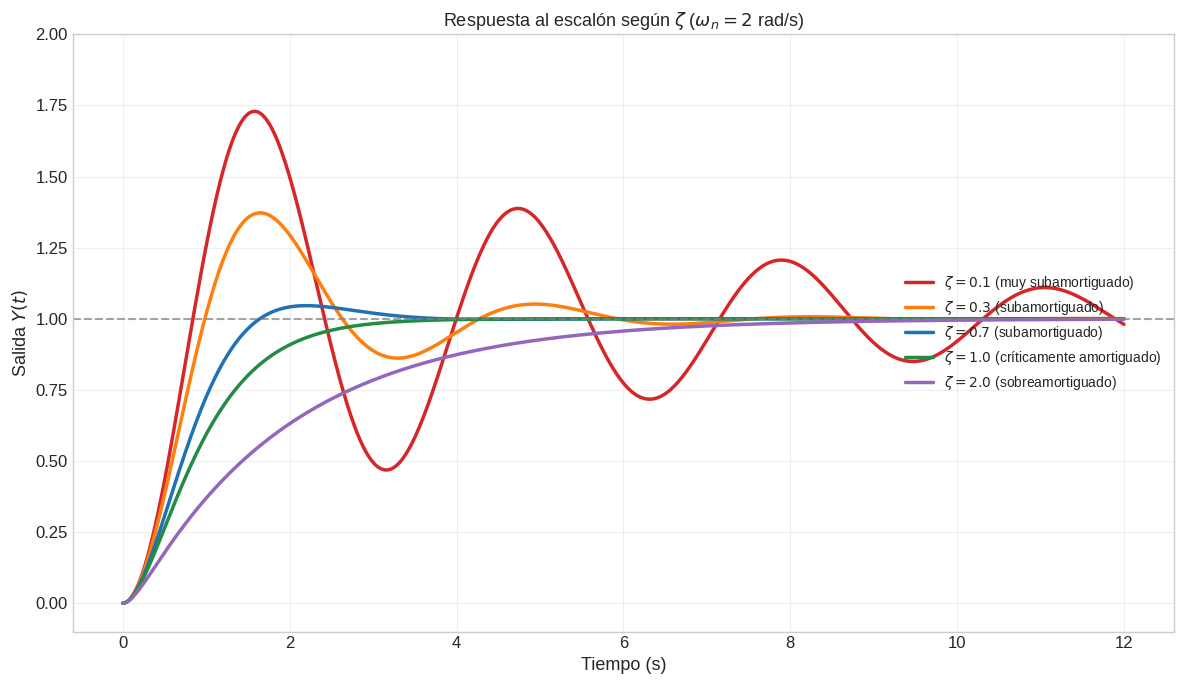

In [9]:
# Efecto del factor de amortiguamiento zeta
wn = 2.0
zetas = [0.1, 0.3, 0.7, 1.0, 2.0]
colores = ['#d62728', '#ff7f0e', COLOR_PRINCIPAL, COLOR_PUNTO, '#9467bd']
etiquetas = [
    r'$\zeta=0.1$ (muy subamortiguado)',
    r'$\zeta=0.3$ (subamortiguado)',
    r'$\zeta=0.7$ (subamortiguado)',
    r'$\zeta=1.0$ (críticamente amortiguado)',
    r'$\zeta=2.0$ (sobreamortiguado)'
]

t_sim = np.linspace(0, 12, 500)

fig, ax = plt.subplots(figsize=(12, 7))

for z, c, label in zip(zetas, colores, etiquetas):
    sys_z = signal.TransferFunction([wn**2], [1, 2*z*wn, wn**2])
    t_out, y_out = signal.step(sys_z, T=t_sim)
    ax.plot(t_out, y_out, color=c, lw=2.5, label=label)

ax.axhline(y=1, color='gray', ls='--', lw=1.5, alpha=0.7)
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel(r'Salida $Y(t)$')
ax.set_title(r'Respuesta al escalón según $\zeta$ ($\omega_n = 2$ rad/s)', fontsize=13)
ax.legend(fontsize=10, loc='right')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 2.0)
plt.tight_layout()
plt.show()

---

## 10. Ejercicios resueltos

#### Ejercicio resuelto 1: Identificar componentes de un sistema de control

**Enunciado:** En un sistema de calefacción doméstica con termostato, identifica $R$, $Y$, $E$, $U$, $P$, el controlador, la planta y el sensor.

**Solución:**

| Componente | Elemento físico |
|:---:|:---|
| $R$ (Referencia) | Temperatura seleccionada en el termostato (ej. 22 °C) |
| $Y$ (Salida) | Temperatura real de la habitación |
| $E$ (Error) | $E = R - Y = 22 - Y$ |
| $U$ (Control) | Potencia entregada por el radiador (ON/OFF o proporcional) |
| $P$ (Perturbación) | Temperatura exterior, ventanas abiertas, personas en la sala |
| Controlador | Termostato (compara $R$ con $Y$ y decide) |
| Planta | Radiador + habitación (sistema térmico) |
| Sensor | Termómetro del termostato |

$$\boxed{\text{Es un sistema de lazo cerrado con control ON-OFF}}$$

#### Ejercicio resuelto 2: Clasificar sistemas

**Enunciado:** Clasifica los siguientes sistemas:

**(a)** Tostadora con temporizador

- **Lazo**: **Abierto** (no mide el tostado, solo cuenta tiempo)
- **Linealidad**: No lineal (el pan cambia de propiedades)
- **Tiempo**: Continuo (el calor fluye continuamente)
- **E/S**: SISO (1 entrada: tiempo, 1 salida: nivel de tostado)

**(b)** Aire acondicionado con termómetro

- **Lazo**: **Cerrado** (mide temperatura y ajusta)
- **Linealidad**: Aproximadamente lineal en rango de operación
- **Tiempo**: Continuo (aunque el compresor puede ser ON/OFF)
- **E/S**: SISO (1 entrada: temperatura deseada, 1 salida: temperatura real)

**(c)** Lavadora con programa fijo

- **Lazo**: **Abierto** (sigue secuencia predefinida, no mide limpieza)
- **Linealidad**: No lineal
- **Tiempo**: Discreto (cambia entre estados: lavar, enjuagar, centrifugar)
- **E/S**: MIMO (varias entradas: agua, detergente, rotación; varias salidas: limpieza, humedad)

$$\boxed{\text{Lazo abierto: tostadora, lavadora} \quad | \quad \text{Lazo cerrado: aire acondicionado}}$$

---

## 11. Catálogo completo de ejercicios: todos los patrones

Esta sección recoge **todos los tipos de ejercicios** que pueden aparecer en exámenes del Tema 1.

| # | Tipo de ejercicio | Habilidad requerida | Dificultad |
|:---:|:---|:---|:---:|
| 1 | Identificar componentes R, E, U, Y, P | Reconocer elementos en un sistema real | Baja |
| 2 | Clasificar lazo abierto / lazo cerrado | Determinar si hay realimentación | Baja |
| 3 | Clasificar lineal / no lineal | Aplicar principio de superposición | Media |
| 4 | Clasificar según múltiples criterios | Aplicar todos los criterios a un sistema | Media |
| 5 | Dibujar diagrama de bloques | Representar un sistema real como diagrama | Media |
| 6 | Calcular error y acción de control | Operaciones numéricas con $E = R - Y$ | Baja |
| 7 | Comparar ventajas/desventajas de realimentación | Razonamiento teórico | Media |
| 8 | Identificar tipo de control (ON-OFF, proporcional, PID) | Reconocer la ley de control | Alta |

### 11.1 Tipo 1: Identificar componentes R, E, U, Y, P

**Método:** Para cualquier sistema real, preguntarse:
1. ¿Qué queremos que pase? $\to$ **Referencia $R$**
2. ¿Qué pasa realmente? $\to$ **Salida $Y$**
3. ¿Cómo actuamos? $\to$ **Señal de control $U$**
4. ¿Qué nos molesta? $\to$ **Perturbación $P$**
5. ¿Cuánto nos equivocamos? $\to$ **Error $E = R - Y$**

$$\boxed{E(t) = R(t) - Y(t)}$$

#### Ejercicio resuelto: Piloto automático de avión

**Enunciado:** Un avión tiene piloto automático para mantener altitud constante.

**Solución:**

- $R$ = altitud deseada (ej. 10 000 m)
- $Y$ = altitud real medida por el altímetro
- $E$ = $R - Y$ = diferencia de altitud
- $U$ = ángulo de los elevadores (timones de profundidad)
- $P$ = corrientes de aire, turbulencias, cambios de peso
- Controlador: ordenador de vuelo
- Planta: aerodinámica del avión
- Sensor: altímetro barométrico + GPS

$$\boxed{\text{Lazo cerrado: el altímetro realimenta la altitud real al controlador}}$$

### 11.2 Tipo 2: Clasificar lazo abierto / lazo cerrado

**Clave:** ¿Se mide la salida y se compara con la referencia?
- **Sí** $\to$ Lazo cerrado
- **No** $\to$ Lazo abierto

**Truco para el examen:** Si el sistema funciona con un temporizador o una secuencia fija $\to$ probablemente **lazo abierto**. Si tiene un sensor que mide la variable de interés $\to$ **lazo cerrado**.

#### Ejercicio resuelto: Clasificar 5 sistemas

| Sistema | ¿Mide la salida? | Clasificación |
|:---|:---:|:---:|
| Secadora con temporizador | No (solo cuenta tiempo) | **Lazo abierto** |
| Horno con termómetro y regulador | Sí (mide temperatura) | **Lazo cerrado** |
| Semáforo con temporizador | No (secuencia fija) | **Lazo abierto** |
| ABS de un coche | Sí (mide velocidad de rueda) | **Lazo cerrado** |
| Grifo manual | No (el usuario mira, pero el sistema no) | **Lazo abierto** |

**Error frecuente:** El grifo manual NO es lazo cerrado aunque el usuario mire el agua. El *sistema* del grifo no tiene sensor: el sensor es el humano, que está fuera del sistema.

### 11.3 Tipo 3: Verificar linealidad

Un sistema es **lineal** si cumple:
1. **Homogeneidad**: $f(\alpha \cdot x) = \alpha \cdot f(x)$
2. **Superposición**: $f(x_1 + x_2) = f(x_1) + f(x_2)$

**Truco para el examen:** Si la ecuación tiene términos independientes, potencias distintas de 1, productos de variables, o funciones no lineales (sen, cos, exp, abs) $\to$ **no lineal**.

#### Ejercicio resuelto: Verificar 4 sistemas

**(a)** $Y = 5U$ $\quad\to$ Lineal (proporción directa, pasa por el origen)

**(b)** $Y = 5U + 3$ $\quad\to$ **No lineal** (término independiente)

Verificación: $f(2) = 13$, $f(3) = 18$, $f(2+3) = f(5) = 28 \neq 13 + 18 = 31$

**(c)** $Y = U^2$ $\quad\to$ **No lineal** (potencia $\neq 1$)

Verificación: $f(2) = 4$, $f(3) = 9$, $f(2+3) = 25 \neq 4 + 9 = 13$

**(d)** $\dot{Y} + 3Y = 2U$ $\quad\to$ **Lineal** (ecuación diferencial lineal de coeficientes constantes)

$$\boxed{\text{Lineales: (a) y (d)} \quad | \quad \text{No lineales: (b) y (c)}}$$

### 11.4 Tipo 4: Clasificación múltiple

**Método:** Aplicar cada criterio sistemáticamente.

#### Ejercicio resuelto: Clasificar un sistema de riego automático

**Enunciado:** Un sistema de riego mide la humedad del suelo con un sensor y activa/desactiva una electroválvula.

| Criterio | Clasificación | Justificación |
|:---|:---|:---|
| Lazo | **Cerrado** | Mide humedad y realimenta |
| Dinámica | **Dinámico** | La humedad depende del historial de riego |
| Linealidad | **No lineal** | La válvula es ON/OFF (no proporcional) |
| Tiempo | **Híbrido** (sensor muestrea $\to$ discreto; planta $\to$ continua) |
| E/S | **SISO** | 1 entrada (referencia humedad), 1 salida (humedad real) |
| Invarianza | **Variante** | Las condiciones del suelo cambian con la estación |

$$\boxed{\text{Lazo cerrado, dinámico, no lineal, híbrido, SISO, variante en el tiempo}}$$

### 11.5 Tipo 5: Dibujar diagrama de bloques

**Método:**
1. Identificar todos los componentes (R, E, U, Y, P)
2. Colocar el sumador ($\Sigma$) a la izquierda
3. Colocar Controlador $\to$ Planta en serie
4. La perturbación entra en la planta (flecha desde arriba)
5. La salida Y se bifurca: una flecha va a la derecha (salida) y otra baja al sensor
6. El sensor realimenta al sumador con signo negativo

#### Ejercicio resuelto: Control de nivel de un depósito de agua

**Enunciado:** Un depósito tiene una boya que mide el nivel. Cuando el nivel baja, se abre una válvula de llenado.

- $R$ = nivel deseado (marcado en la boya)
- $Y$ = nivel real del agua
- $E$ = $R - Y$
- $U$ = apertura de la válvula de entrada
- $P$ = consumo de agua (grifo abierto)
- Controlador: mecanismo de la boya
- Planta: depósito
- Sensor: boya flotante

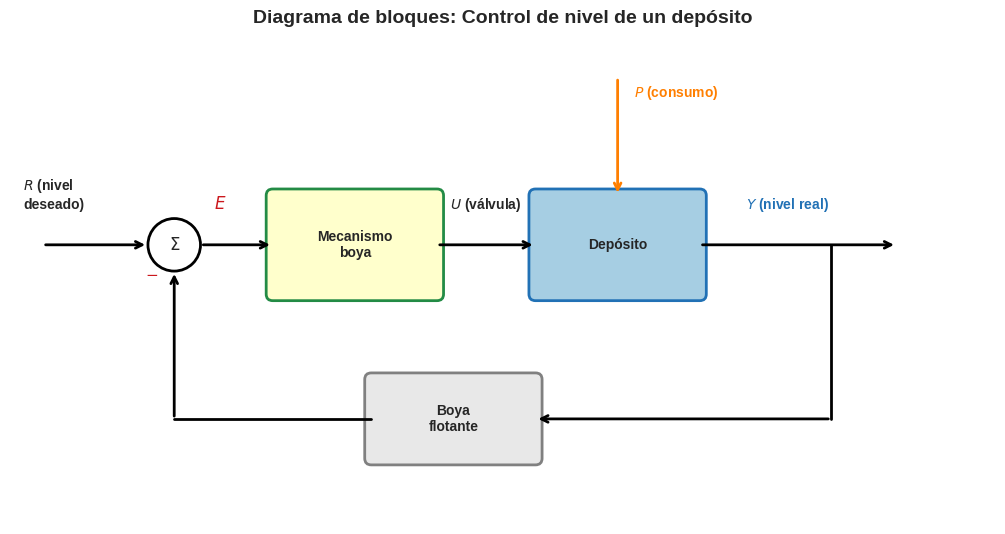

In [10]:
# Diagrama de bloques: Control de nivel de un depósito de agua
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.set_xlim(0, 15)
ax.set_ylim(-1.5, 6)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(r'Diagrama de bloques: Control de nivel de un depósito', fontsize=14, fontweight='bold')

# Sumador
circle = plt.Circle((2.5, 2.75), 0.4, fill=False, edgecolor='black', lw=2)
ax.add_patch(circle)
ax.text(2.5, 2.75, r'$\Sigma$', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(2.05, 2.25, r'$-$', fontsize=11, color=COLOR_RECTA, fontweight='bold')

# Controlador (Boya)
b1 = FancyBboxPatch((4, 2), 2.5, 1.5, boxstyle='round,pad=0.1',
                      facecolor='#ffffcc', edgecolor=COLOR_PUNTO, lw=2)
ax.add_patch(b1)
ax.text(5.25, 2.75, 'Mecanismo\nboya', ha='center', va='center', fontsize=10, fontweight='bold')

# Planta (Depósito)
b2 = FancyBboxPatch((8, 2), 2.5, 1.5, boxstyle='round,pad=0.1',
                      facecolor=COLOR_CLARO, edgecolor=COLOR_PRINCIPAL, lw=2)
ax.add_patch(b2)
ax.text(9.25, 2.75, r'Depósito', ha='center', va='center', fontsize=10, fontweight='bold')

# Sensor (Boya flotante)
b3 = FancyBboxPatch((5.5, -0.5), 2.5, 1.2, boxstyle='round,pad=0.1',
                      facecolor='#e8e8e8', edgecolor='gray', lw=2)
ax.add_patch(b3)
ax.text(6.75, 0.1, 'Boya\nflotante', ha='center', va='center', fontsize=10, fontweight='bold')

# Flechas
ax.annotate('', xy=(2.1, 2.75), xytext=(0.5, 2.75),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.text(0.2, 3.3, r'$R$ (nivel' + '\n' + 'deseado)', fontsize=10, fontweight='bold')

ax.annotate('', xy=(4, 2.75), xytext=(2.9, 2.75),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.text(3.1, 3.3, r'$E$', fontsize=12, fontweight='bold', color=COLOR_RECTA)

ax.annotate('', xy=(8, 2.75), xytext=(6.5, 2.75),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.text(6.7, 3.3, r'$U$ (válvula)', fontsize=10, fontweight='bold')

ax.annotate('', xy=(13.5, 2.75), xytext=(10.5, 2.75),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.text(11.2, 3.3, r'$Y$ (nivel real)', fontsize=10, fontweight='bold', color=COLOR_PRINCIPAL)

ax.annotate('', xy=(9.25, 3.5), xytext=(9.25, 5.3),
            arrowprops=dict(arrowstyle='->', lw=2, color=COLOR_PERTURB))
ax.text(9.5, 5, r'$P$ (consumo)', fontsize=10, fontweight='bold', color=COLOR_PERTURB)

# Realimentación
ax.plot([12.5, 12.5], [2.75, 0.1], color='black', lw=2)
ax.annotate('', xy=(8, 0.1), xytext=(12.5, 0.1),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.plot([5.5, 2.5], [0.1, 0.1], color='black', lw=2)
ax.annotate('', xy=(2.5, 2.35), xytext=(2.5, 0.1),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))

plt.tight_layout()
plt.show()

### 11.6 Tipo 6: Calcular error y acción de control

**Fórmulas clave:**

$$\boxed{E(t) = R(t) - Y(t)}$$

$$\boxed{U(t) = G_c \cdot E(t) \quad \text{(control proporcional)}}$$

#### Ejercicio resuelto: Cálculo de error y acción de control

**Datos:** Un sistema de control de presión tiene: $R = 5$ bar, $Y = 4.2$ bar, $K_p = 3$ (ganancia proporcional del controlador).

**Paso 1:** Calcular el error

$$E = R - Y = 5 - 4.2 = 0.8\;\text{bar}$$

**Paso 2:** Calcular la acción de control (proporcional)

$$U = K_p \cdot E = 3 \times 0.8 = 2.4\;\text{V (señal al actuador)}$$

**Paso 3:** Interpretar

El controlador envía 2.4 V al actuador (válvula), que abrirá más para aumentar la presión.

$$\boxed{E = 0.8\;\text{bar}, \quad U = 2.4\;\text{V}}$$

### 11.7 Tipo 7: Ventajas y desventajas de la realimentación

**Ventajas del lazo cerrado sobre el lazo abierto:**

1. **Reduce el efecto de perturbaciones** por un factor $\frac{1}{1 + G_c \cdot G_p}$
2. **Reduce la sensibilidad** a cambios en los parámetros de la planta
3. **Mejora la precisión** (el error en régimen permanente disminuye)
4. **Mejora la velocidad** de respuesta (puede ajustarse con la ganancia)

**Desventajas:**

1. **Puede ser inestable** si la ganancia es demasiado alta
2. **Más complejo y costoso** (necesita sensor, controlador)
3. **El sensor introduce ruido** en la medida

#### Ejercicio resuelto: Comparar lazo abierto y cerrado

**Datos:** $G_p = 10$, $G_c = 2$, $R = 1$. La planta cambia un 20% ($G_p' = 12$).

**Lazo abierto:**

$$Y = G_c \cdot G_p \cdot R = 2 \times 10 \times 1 = 20 \quad \text{(nominal)}$$
$$Y' = 2 \times 12 \times 1 = 24 \quad \text{(con cambio)}$$
$$\text{Variación} = \frac{24 - 20}{20} \times 100 = 20\%$$

**Lazo cerrado:**

$$Y = \frac{G_c \cdot G_p}{1 + G_c \cdot G_p} \cdot R = \frac{20}{21} = 0.952$$
$$Y' = \frac{2 \times 12}{1 + 2 \times 12} = \frac{24}{25} = 0.960$$
$$\text{Variación} = \frac{0.960 - 0.952}{0.952} \times 100 = 0.84\%$$

$$\boxed{\text{Lazo abierto: 20\% de variación} \quad vs \quad \text{Lazo cerrado: 0.84\% de variación}}$$

La realimentación redujo la sensibilidad al cambio de parámetros de 20% a menos del 1%.

### 11.8 Tipo 8: Identificar el tipo de control

Los principales tipos de acción de control son:

| Tipo | Ley de control | Característica |
|:---|:---|:---|
| **ON-OFF** (todo o nada) | $U = U_{max}$ si $E > 0$; $U = 0$ si $E < 0$ | Simple, barato, oscila |
| **Proporcional (P)** | $U = K_p \cdot E$ | Rápido, pero tiene error en régimen permanente |
| **Proporcional-Integral (PI)** | $U = K_p \cdot E + K_i \int E\,dt$ | Elimina error permanente |
| **PID** | $U = K_p \cdot E + K_i \int E\,dt + K_d \frac{dE}{dt}$ | El más completo, anticipa el futuro |

$$\boxed{U_{PID} = K_p \cdot E(t) + K_i \int_0^t E(\tau)\,d\tau + K_d \frac{dE(t)}{dt}}$$

#### Ejercicio resuelto: Identificar el tipo de control

**(a)** Un termostato que enciende la calefacción si $T < 20$ °C y la apaga si $T > 22$ °C $\to$ **ON-OFF con histéresis**

**(b)** Un regulador que envía al motor una tensión igual a 3 veces el error de velocidad $\to$ **Proporcional** ($K_p = 3$)

**(c)** Un controlador industrial que ajusta el caudal usando el error actual, la acumulación del error pasado, y la tendencia del error $\to$ **PID**

$$\boxed{\text{(a) ON-OFF} \quad | \quad \text{(b) Proporcional} \quad | \quad \text{(c) PID}}$$

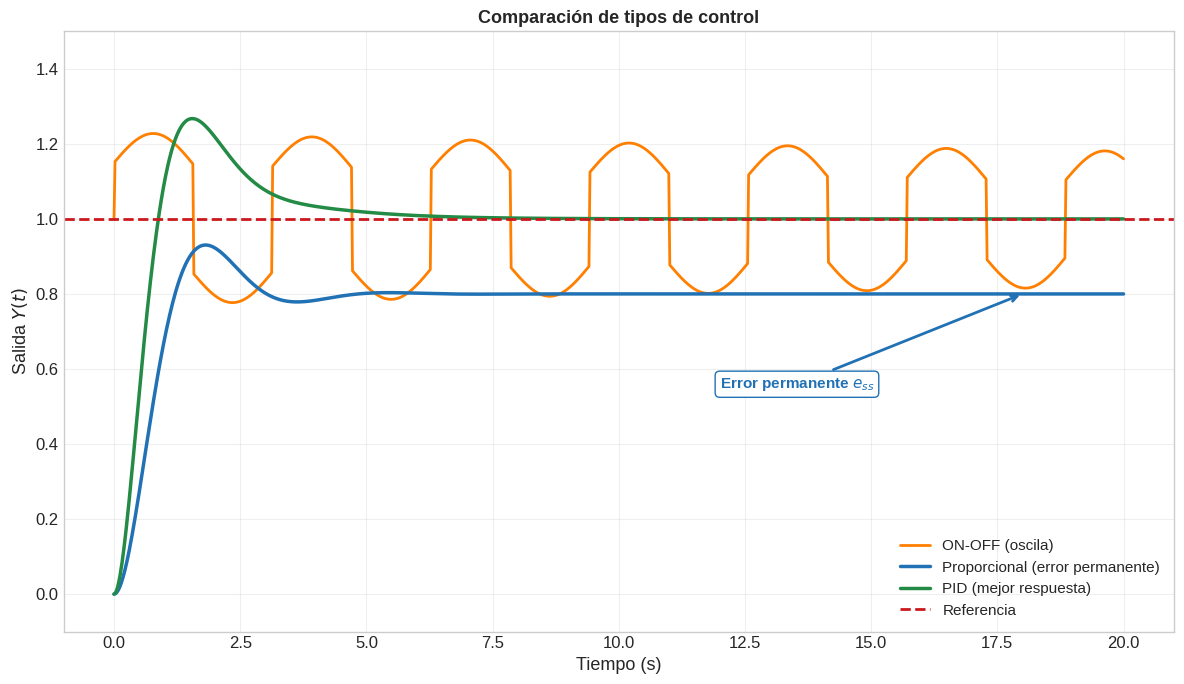

In [11]:
# Comparación visual: Control ON-OFF vs Proporcional vs PID
t = np.linspace(0, 20, 1000)

# Simular respuestas típicas
# ON-OFF: oscila alrededor de la referencia
y_onoff = 1 + 0.15 * np.sign(np.sin(2 * t)) * np.exp(-0.02 * t) + 0.08 * np.sin(2 * t)

# Proporcional: rápido pero con error permanente
sys_p = signal.TransferFunction([4], [1, 2, 4])  # zeta=0.5, wn=2
t_p, y_p_raw = signal.step(sys_p, T=t)
y_proporcional = 0.8 * y_p_raw  # error permanente del 20%

# PID: rápido, sin error permanente, pequeño sobrepico
sys_pid = signal.TransferFunction([8, 4], [1, 4, 8, 4])  # bien ajustado
t_pid, y_pid = signal.step(sys_pid, T=t)

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(t, y_onoff, color=COLOR_PERTURB, lw=2, label='ON-OFF (oscila)')
ax.plot(t_p, y_proporcional, color=COLOR_PRINCIPAL, lw=2.5, label=r'Proporcional (error permanente)')
ax.plot(t_pid, y_pid, color=COLOR_PUNTO, lw=2.5, label='PID (mejor respuesta)')
ax.axhline(y=1, color=COLOR_RECTA, ls='--', lw=2, label='Referencia')

# Anotar error permanente del proporcional
ax.annotate(r'Error permanente $e_{ss}$',
            xy=(18, y_proporcional[-1]), xytext=(12, 0.55),
            fontsize=11, color=COLOR_PRINCIPAL, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PRINCIPAL, lw=2),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PRINCIPAL))

ax.set_xlabel('Tiempo (s)')
ax.set_ylabel(r'Salida $Y(t)$')
ax.set_title(r'Comparación de tipos de control', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 1.5)
plt.tight_layout()
plt.show()

---

## 12. Resumen y fórmulas clave

| Concepto | Fórmula / Definición | Uso |
|:---|:---|:---|
| Error | $E(t) = R(t) - Y(t)$ | Base de todo control en lazo cerrado |
| Salida lazo cerrado | $Y = \dfrac{G_c \cdot G_p}{1 + G_c \cdot G_p} \cdot R$ | Calcular salida en régimen permanente |
| Efecto perturbación (lazo cerrado) | $Y_P = \dfrac{G_p}{1 + G_c \cdot G_p} \cdot P$ | El efecto se reduce por $1 + G_c G_p$ |
| Control proporcional | $U = K_p \cdot E$ | Acción proporcional al error |
| Control PID | $U = K_p E + K_i \int E\,dt + K_d \dot{E}$ | Acción completa: P + I + D |
| Sobreoscilación | $M_p = e^{-\frac{\zeta \pi}{\sqrt{1-\zeta^2}}}$ | Para sistemas de 2º orden |
| Tiempo de pico | $t_p = \dfrac{\pi}{\omega_n\sqrt{1-\zeta^2}}$ | Primer máximo de la respuesta |
| Tiempo de establecimiento | $t_s \approx \dfrac{4}{\zeta \cdot \omega_n}$ | Criterio del 2% |
| Sistema lineal | Cumple superposición y homogeneidad | Requisito para técnicas LTI |
| Lazo cerrado | Tiene sensor + comparador + realimentación | Corrige errores automáticamente |

**Recuerda:** En el examen, lo primero es identificar si el sistema es de lazo abierto o cerrado. Si es cerrado, identificar R, E, U, Y, P. Si piden clasificar, aplicar cada criterio por separado.

---

*Notebook generado para la asignatura Fundamentos de Control - GIERM. Tema 1: Sistemas de Control Automático.*